# 3-Step Grid Search: Model Class Comparison

Compare three model classes from the (σ₀, σ₁, σ₂) grid search against the human d' curve:
1. **3-step**: σ₀ > 0 and σ₁ > σ₂ (encoding noise + two-regime drift)
2. **2-step**: σ₀ = 0 and σ₁ > σ₂ (no encoding noise, two-regime drift)
3. **Constant noise**: σ₀ = 0 and σ₁ = σ₂ (single diffusion rate)

Only models satisfying σ₀ ≥ σ₁ ≥ σ₂ are considered.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Results directory ──
RESULTS_DIR = (
    '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t5_nmc1_task0'
)

#/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t5_nmc1_task0/
# ── Load merged grid search results ──
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_3step_t5.npz'))
sigma0_grid = grid['sigma0_grid']
sigma1_grid = grid['sigma1_grid']
sigma2_grid = grid['sigma2_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

# 3D d' arrays: results[isi][i_s0, i_s1, i_s2]
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# ── Flatten into DataFrame ──
rows = []
for i0, s0 in enumerate(sigma0_grid):
    for i1, s1 in enumerate(sigma1_grid):
        for i2, s2 in enumerate(sigma2_grid):
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2,
                   'i_s0': i0, 'i_s1': i1, 'i_s2': i2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i0, i1, i2]
            rows.append(row)

df = pd.DataFrame(rows)
print(f'Total grid points: {len(df)}')
print(f'Grid: {len(sigma0_grid)} x {len(sigma1_grid)} x {len(sigma2_grid)}')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma1: {sigma1_grid}')
print(f'sigma2: {sigma2_grid}')

Total grid points: 3375
Grid: 15 x 15 x 15
ISI values: (0, 1, 2, 4, 8, 16, 32, 64)
sigma0: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma1: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma2: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]


In [2]:
# ── Load human d' curve ──
from utls.runners_utils import load_experiment_data, compute_human_curve

which_task = 0   # first multi-ISI task
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full = np.array([0, 1, 2, 4, 8, 16, 32, 64])
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)

# Grid ISIs (from npz) may not include ISI=3 — align to grid
grid_isis = np.array(ISI_VALUES)
mask = np.isin(human_isis_full, grid_isis)
human_dp = human_curve_full[mask]
isis = human_isis_full[mask]

assert len(human_dp) == len(grid_isis), (
    f'Mismatch: human has {len(human_dp)} ISIs, grid has {len(grid_isis)}'
)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Human participants: {len(human_runs)}')
print(f'Aligned ISIs: {isis}')
print(f'Human d\': {np.round(human_dp, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature (env-sounds)
Human participants: 104
Aligned ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [3.384 2.962 2.383 2.077 1.946 1.861 1.735 1.561]


In [ ]:
# ── Filter: sigma0 >= sigma1 >= sigma2 ──
decreasing = (df['sigma0'] >= df['sigma1']) & (df['sigma1'] >= df['sigma2'])
df_filt = df.copy()
print(f'Decreasing constraint: {len(df_filt)}/{len(df)} triples kept')

# ── Classify model types ──
def classify(row):
    s0, s1, s2 = row['sigma0'], row['sigma1'], row['sigma2']
    if s0 == s1 and s1 == s2:
        return 'constant'
    elif (s0 == s1 and s1 > s2) or (s0 == 0 and s1 > s2):
        return '2-step'
    elif s0 > 0 and s0 > s1 and s1 > s2:
        return '3-step'
    else:
        return 'other'

df_filt['model_class'] = df_filt.apply(classify, axis=1)
print('\nModel class counts:')
print(df_filt['model_class'].value_counts().to_string())

Decreasing constraint: 3375/3375 triples kept

Model class counts:
model_class
other       2695
3-step       455
2-step       210
constant      15


In [6]:
# ── Compute MSE to human curve ──
dp_cols = [f'dprime_isi{isi}' for isi in grid_isis]
model_dp_matrix = df_filt[dp_cols].values  # (n_models, n_isis)

# MSE per model (ignoring NaN entries)
diff = model_dp_matrix - human_dp[np.newaxis, :]
mse = np.nanmean(diff**2, axis=1)
df_filt['mse'] = mse

# Drop rows that are all NaN
df_filt = df_filt.dropna(subset=['mse'])
print(f'Models with valid MSE: {len(df_filt)}')
print(f'MSE range: {df_filt["mse"].min():.4f} – {df_filt["mse"].max():.4f}')

Models with valid MSE: 3368
MSE range: 0.0340 – 20.4560


/tmp/ipykernel_3377877/4011528738.py:7: RuntimeWarning: Mean of empty slice
  mse = np.nanmean(diff**2, axis=1)


In [13]:
# ── Best models per class ──
N_BEST = 5
CLASS_ORDER = ['3-step', '2-step', 'constant']

best_per_class = {}
for cls in CLASS_ORDER:
    sub = df_filt[df_filt['model_class'] == cls].nsmallest(N_BEST, 'mse')
    best_per_class[cls] = sub
    if len(sub) == 0:
        print(f'\n=== {cls}: no models ===')
        continue
    print(f'\n=== {cls} (n={len(df_filt[df_filt["model_class"]==cls])}) — top {len(sub)} by MSE ===')
    display_cols = ['sigma0', 'sigma1', 'sigma2', 'mse']
    print(sub[display_cols].to_string(index=False, float_format='{:.4f}'.format))


=== 3-step (n=454) — top 5 by MSE ===
 sigma0  sigma1  sigma2    mse
13.6949  2.2512  0.6756 0.0340
13.6949  2.2512  0.3701 0.0837
13.6949  1.2332  0.6756 0.0851
13.6949  2.2512  0.2027 0.1414
13.6949  2.2512  0.1111 0.1639

=== 2-step (n=209) — top 5 by MSE ===
 sigma0  sigma1  sigma2    mse
 0.6756  0.6756  0.0000 2.4530
 0.6756  0.6756  0.0100 2.4566
 0.6756  0.6756  0.0183 2.4650
 0.6756  0.6756  0.0333 2.4922
 0.6756  0.6756  0.0608 2.5781

=== constant (n=15) — top 5 by MSE ===
 sigma0  sigma1  sigma2    mse
 0.6756  0.6756  0.6756 3.4497
25.0000 25.0000 25.0000 3.8314
13.6949 13.6949 13.6949 3.9081
 7.5021  7.5021  7.5021 4.1276
 4.1096  4.1096  4.1096 4.3291


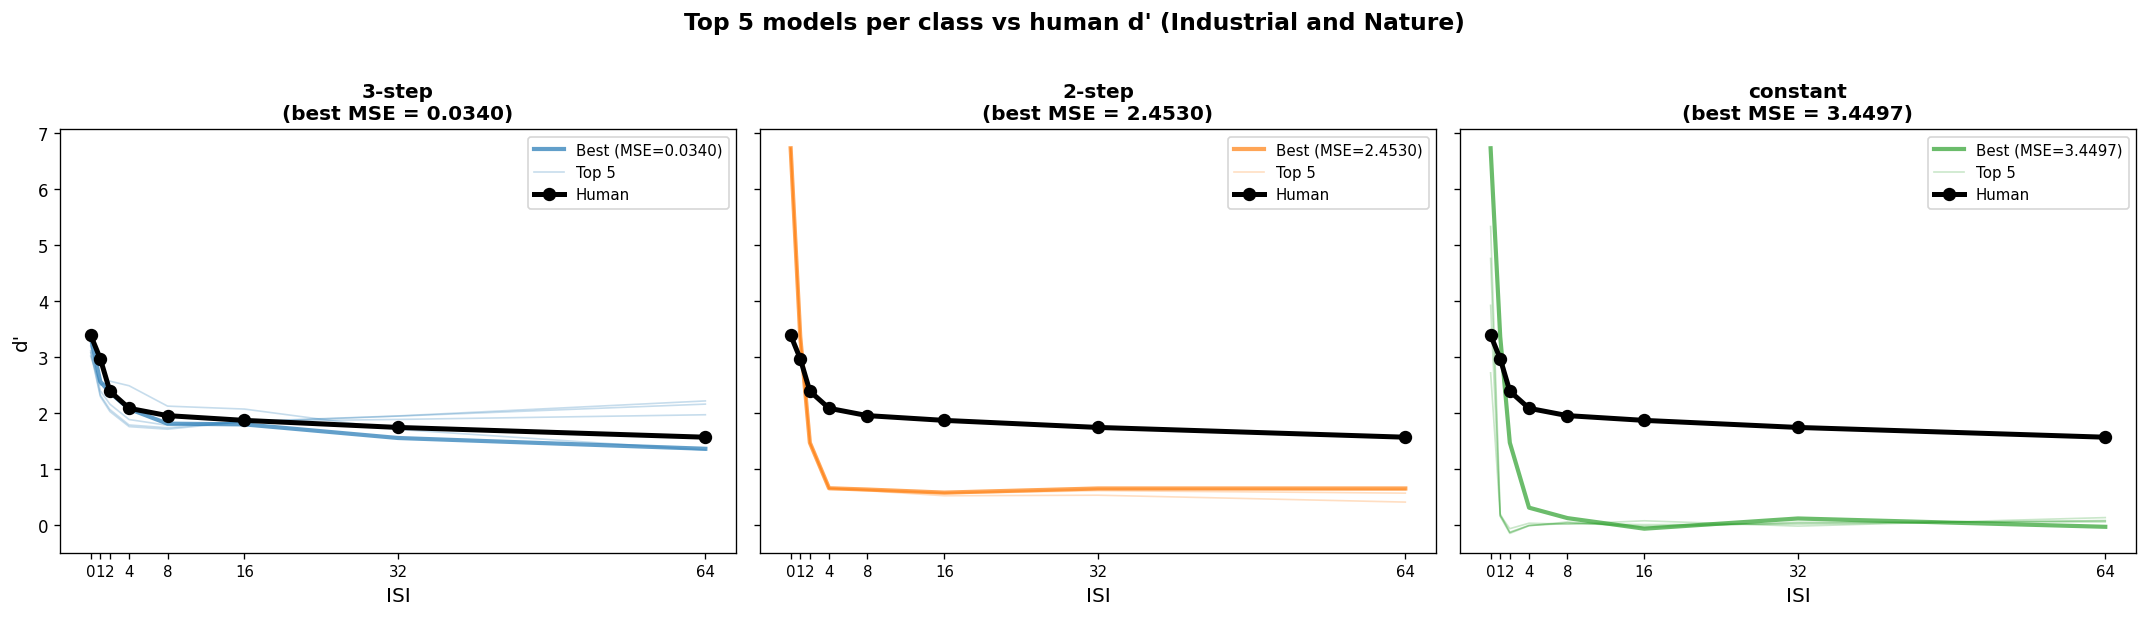

In [14]:
# ── Plot: best models per class vs human curve ──
CLASS_COLORS = {'3-step': 'tab:blue', '2-step': 'tab:orange', 'constant': 'tab:green'}

# Use ISI values themselves for x-coordinates for correct spacing
x = np.array(grid_isis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cls in zip(axes, CLASS_ORDER):
    sub = best_per_class[cls]
    color = CLASS_COLORS[cls]

    # Plot each model curve
    for i, (_, row) in enumerate(sub.iterrows()):
        model_curve = row[dp_cols].values.astype(float)
        alpha = 0.7 if i == 0 else 0.25
        lw = 2.5 if i == 0 else 1.0
        label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)
        ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

    # Human curve
    ax.plot(x, human_dp, 'o-k', linewidth=3, markersize=7, label='Human', zorder=10)

    ax.set_xticks(x)
    ax.set_xticklabels(grid_isis, fontsize=9)
    ax.set_xlabel('ISI', fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("d'", fontsize=12)
    ax.set_title(f'{cls}\n(best MSE = {sub["mse"].min():.4f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle(f"Top {N_BEST} models per class vs human d' ({hr_task_name})",
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

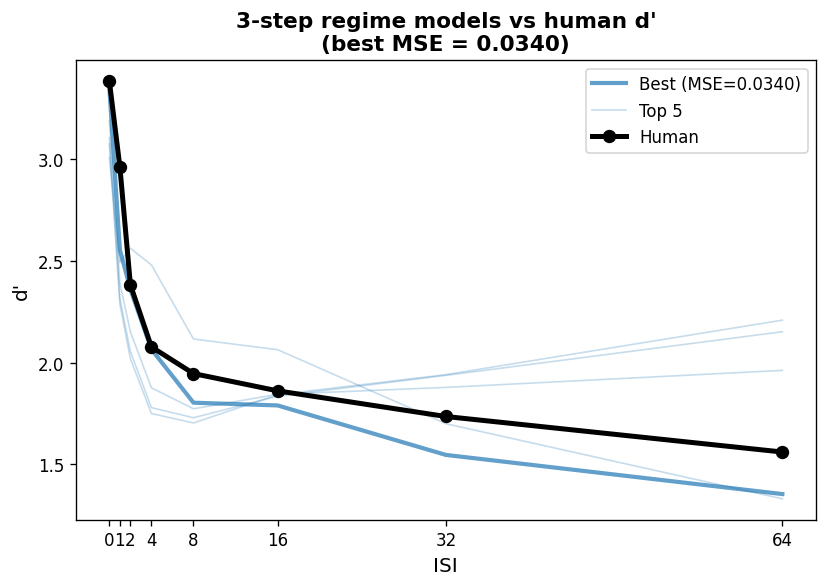

In [16]:
# ── Plot: 3-step regime models vs human curve ──

fig, ax = plt.subplots(figsize=(7, 5))
# Use ISI values themselves for x-coordinates for correct spacing
x = np.array(grid_isis)
cls = '3-step'
sub = best_per_class[cls]
color = CLASS_COLORS[cls]

# Plot each model curve
for i, (_, row) in enumerate(sub.iterrows()):
    model_curve = row[dp_cols].values.astype(float)
    alpha = 0.7 if i == 0 else 0.25
    lw = 2.5 if i == 0 else 1.0
    label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)
    ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

# Human curve
ax.plot(x, human_dp, 'o-k', linewidth=3, markersize=7, label='Human', zorder=10)

ax.set_xticks(x)
ax.set_xticklabels(grid_isis, fontsize=10)
ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("d'", fontsize=12)
ax.set_title(f"3-step regime models vs human d'\n(best MSE = {sub['mse'].min():.4f})", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()

Model class  N models  Best MSE  Mean top-5 MSE   Best σ₀  Best σ₁  Best σ₂
     3-step       454  0.033960        0.101604 13.694936 2.251231 0.675554
     2-step       209  2.453000        2.488964  0.675554 0.675554 0.000000
   constant        15  3.449748        3.929209  0.675554 0.675554 0.675554


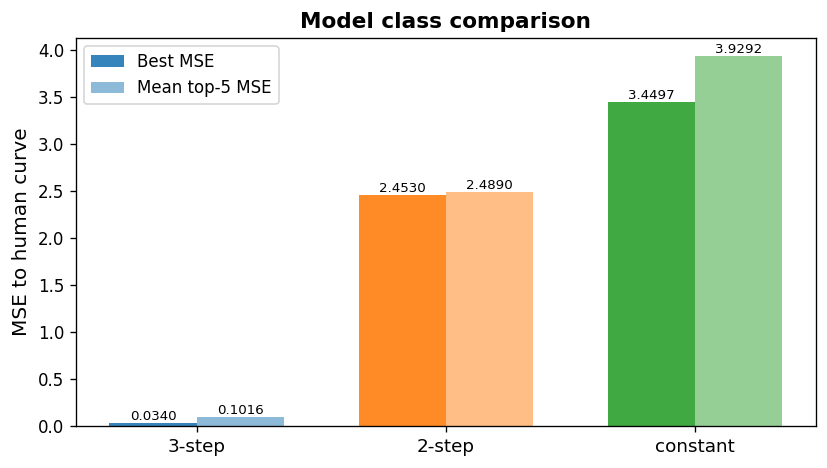

In [17]:
# ── Summary: MSE comparison across classes ──
summary_rows = []
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    n_total = len(df_filt[df_filt['model_class'] == cls])
    if len(sub) == 0:
        continue
    best_row = sub.iloc[0]
    summary_rows.append({
        'Model class': cls,
        'N models': n_total,
        'Best MSE': sub['mse'].min(),
        f'Mean top-{N_BEST} MSE': sub['mse'].mean(),
        'Best σ₀': best_row['sigma0'],
        'Best σ₁': best_row['sigma1'],
        'Best σ₂': best_row['sigma2'],
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# ── Bar plot ──
fig, ax = plt.subplots(figsize=(7, 4))
classes = summary['Model class']
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, summary['Best MSE'], width,
               label='Best MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.9)
bars2 = ax.bar(x + width/2, summary[f'Mean top-{N_BEST} MSE'], width,
               label=f'Mean top-{N_BEST} MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel('MSE to human curve', fontsize=12)
ax.set_title('Model class comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Add value labels
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()

In [18]:
# ── Store best parameters for downstream use ──
print('\nBest parameters per class:')
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    if len(sub) == 0:
        continue
    best = sub.iloc[0]
    print(f'  {cls}: σ₀={best["sigma0"]:.4f}, σ₁={best["sigma1"]:.4f}, '
          f'σ₂={best["sigma2"]:.4f}  (MSE={best["mse"]:.4f})')


Best parameters per class:
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.6756  (MSE=0.0340)
  2-step: σ₀=0.6756, σ₁=0.6756, σ₂=0.0000  (MSE=2.4530)
  constant: σ₀=0.6756, σ₁=0.6756, σ₂=0.6756  (MSE=3.4497)
